# Compare the Taichi and XLB flow solvers

This notebook runs the same porous-medium simulation through both `kabs` backends, then compares runtime, convergence metadata, permeability, and a velocity cross-section.

The XLB backend is optional. Install it before running this notebook (for example, `pip install xlb` for CPU/JAX), then restart the kernel.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import taichi as ti
import xlb

from kabs import compute_permeability, solve_flow

# The Taichi implementation requires explicit initialization.
# Use ti.gpu here when a supported GPU backend is available.
ti.init(arch=ti.cpu)

[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.12.11


[I 08/02/26 20:15:47.608 1569778] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


[Taichi] Starting on arch=arm64


## Build a shared test geometry

The image uses the public `kabs` convention: `1` is pore space and `0` is solid. Four cylindrical pores run in the flow direction.

In [2]:
def bundle_of_tubes(length=30, width=50, radius=10):
    """Return four cylindrical pores aligned with the x axis."""
    y, z = np.mgrid[0:width, 0:width]
    centres = ((13, 13), (13, 37), (37, 13), (37, 37))
    cross_section = np.zeros((width, width), dtype=bool)
    for centre_y, centre_z in centres:
        cross_section |= (y - centre_y) ** 2 + (z - centre_z) ** 2 <= radius**2
    return np.broadcast_to(cross_section, (length, width, width)).copy().astype(np.int8)

im = bundle_of_tubes()
print(f"Image shape: {im.shape}; porosity: {im.mean():.3f}")

Image shape: (30, 50, 50); porosity: 0.507


## Solve with each backend

Both calls use identical physical and convergence settings. The first XLB/JAX call includes JIT compilation, so its elapsed time is useful for end-to-end comparison but not a steady-state throughput benchmark.

In [ ]:
solve_options = dict(
    direction="x",
    n_steps=4_000,
    nu=1.0 / 6.0,
    log_every=200,
    tol=1e-3,
    verbose=False,
)

started = time.perf_counter()
taichi_result = solve_flow(
    im, 
    backend="taichi", 
    **solve_options,
)
taichi_seconds = time.perf_counter() - started

started = time.perf_counter()
xlb_result = solve_flow(
    im, 
    backend="xlb", 
    compute_backend="jax", 
    **solve_options,
)
xlb_seconds = time.perf_counter() - started

: 

In [4]:
taichi_permeability = compute_permeability(taichi_result, verbose=False)
xlb_permeability = compute_permeability(xlb_result, verbose=False)

rows = (
    ("Taichi", taichi_result, taichi_permeability, taichi_seconds),
    ("XLB (JAX)", xlb_result, xlb_permeability, xlb_seconds),
)

print(f"{'Backend':<12} {'Seconds':>9} {'Steps':>7} {'Criterion':>12} {'k [voxels²]':>15}")
print("-" * 62)
for name, result, permeability, seconds in rows:
    criterion = result.convergence_criterion
    criterion_text = "not checked" if criterion is None else f"{criterion:.2e}"
    print(
        f"{name:<12} {seconds:>9.2f} {result.n_iterations:>7} "
        f"{criterion_text:>12} {permeability['k_lu']:>15.6e}"
    )

relative_difference = abs(xlb_permeability['k_lu'] - taichi_permeability['k_lu']) / taichi_permeability['k_lu']
print(f"\nRelative permeability difference: {relative_difference:.2%}")

Backend        Seconds   Steps    Criterion     k [voxels²]
--------------------------------------------------------------
Taichi            2.88    1000     5.11e-04    6.421813e+00
XLB (JAX)        21.85    1000     3.29e-04    6.405047e+00

Relative permeability difference: 0.26%


## Inspect the velocity fields

This shows the x-velocity on the middle x-plane. The shared colour scale makes visual differences easier to spot.

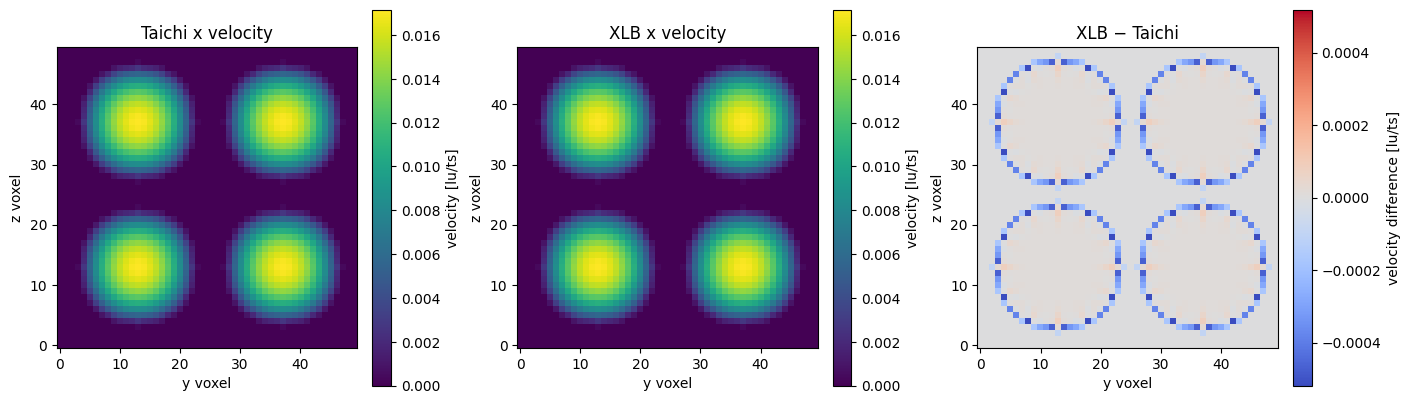

In [5]:
midpoint = im.shape[0] // 2
taichi_velocity = taichi_result.velocity[midpoint, ..., 0]
xlb_velocity = xlb_result.velocity[midpoint, ..., 0]
limit = max(np.abs(taichi_velocity).max(), np.abs(xlb_velocity).max())

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for axis, velocity, title in (
    (axes[0], taichi_velocity, "Taichi x velocity"),
    (axes[1], xlb_velocity, "XLB x velocity"),
):
    image = axis.imshow(velocity.T, origin="lower", cmap="viridis", vmin=0, vmax=limit)
    axis.set(title=title, xlabel="y voxel", ylabel="z voxel")
    fig.colorbar(image, ax=axis, label="velocity [lu/ts]")

difference = xlb_velocity - taichi_velocity
difference_limit = np.abs(difference).max()
image = axes[2].imshow(difference.T, origin="lower", cmap="coolwarm", vmin=-difference_limit, vmax=difference_limit)
axes[2].set(title="XLB − Taichi", xlabel="y voxel", ylabel="z voxel")
fig.colorbar(image, ax=axes[2], label="velocity difference [lu/ts]")
plt.show()

For a fair repeated-run timing comparison, rerun the XLB solve after its first JIT compilation. For GPU experiments, change the Taichi `arch` setting above and choose the appropriate XLB installation and `compute_backend`.